# Proyecto: Dinámica del dólar en periodos de estrés y regímenes de mercado

Este proyecto analiza el comportamiento del tipo de cambio USD/MXN desde una perspectiva macroeconómica y cuantitativa, con énfasis en periodos de crisis global como la pandemia de COVID-19. El objetivo no es establecer relaciones rígidas o permanentes entre variables, sino entender cómo estas cambian dependiendo del entorno económico.

Bajo este enfoque, la investigación se centra en la siguiente pregunta:



In [2]:
import importlib
import macro_analysis.macro_tools as rrm
importlib.reload(rrm)

import Quant_Finance_Project.capm as capm
importlib.reload(capm)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 

# Análisis de Estados Unidos
Para el caso de Estados Unidos, trabajamos con TIPS a 5 y 10 años, además de los U.S. T Notes (DGS) de 5 y 10 años, en adición a nuestros índices de interés, que son el principal *scoop* del proyecto.

*Cabe mencionar que todo el código y nuestras herramientas permiten de forma dinámica agregar cualquier varialbe nueva que sea de nuestro interés.*

#### Diferenciación por horizonte: expectativas de inflación a 5 y 10 años

Con el objetivo de profundizar en el análisis de la dinámica macro-financiera, se extiende el estudio de inflación esperada incorporando dos horizontes temporales: mediano plazo (5 años) y largo plazo (10 años).

Esta distinción es relevante, ya que las expectativas de inflación no son homogéneas a lo largo de la curva temporal. 

Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/EXP_INF_USA5.csv
Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/EXP_INF_USA10.csv


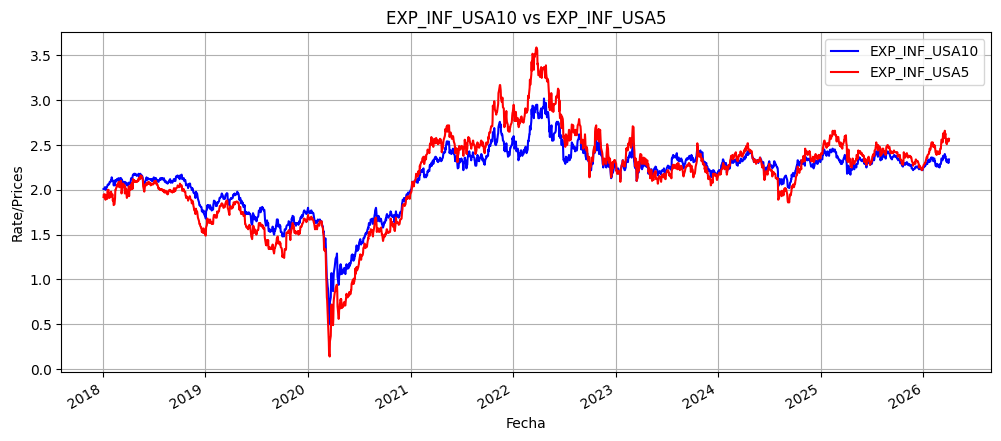

In [111]:
# Obtener la inflación esperada implícita de Estados Unidos a 5 años (derivada de la diferencia entre tasas nominales y reales)
expected_inflation_usa_5 = rrm.synchronise_timseries_df('DGS5', 'TIPS5', 'Tasa', 'Tasa', dif = True)
rrm.cargar_archivo(expected_inflation_usa_5, archivo = 'EXP_INF_USA5')

# Obtener la inflación esperada implícita de Estados Unidos a 10 años (derivada de la diferencia entre tasas nominales y reales)
expected_inflation_usa_10 = rrm.synchronise_timseries_df('DGS10', 'TIPS10', 'Tasa', 'Tasa', dif = True)
rrm.cargar_archivo(expected_inflation_usa_10, archivo = 'EXP_INF_USA10')

rrm.plot_two_timeseries('EXP_INF_USA10', 'EXP_INF_USA5', 'Diferencia', 'Diferencia', titulo = "EXP_INF_USA10 vs EXP_INF_USA5", secondary_y=False)

In [115]:
m = rrm.model('EXP_INF_USA10', 'EXP_INF_USA5', 6)
m.synchronise_timeseries()
m.compute_linear_reg()

print(f"From: {m.timeseries['Fecha'].min()} - To: {m.timeseries['Fecha'].max()}")        
print(f"Corr: {m.correlation}, R2: {m.r_squared}")

From: 2018-01-04 00:00:00 - To: 2026-04-02 00:00:00
Corr: 0.855085, R2: 0.731171


**Mientras que los horizontes de menor plazo tienden a ser más sensibles a condiciones económicas actuales, política monetaria y episodios de estrés, los horizontes de largo plazo suelen reflejar expectativas más estables y ancladas.**

Por ende, realizaremos un estudio considerando distintos horizontes temporales, específicamente a 5 y 10 años, evaluandolos en distintos periodos de tiempo. Esta extensión nos permitirá corroborar si ambos horizontes siguen el mismo comportamiento macro-financiero o no (que por el anterior párrafo no debería) y si presentan diferencias relevantes dependiendo del periodo de tiempo considerado.

Dicho de otra manera, el propósito de este análisis no es únicamente identificar relaciones entre variables, sino entender cómo estas pueden variar en función del horizonte temporal, ya que las expectativas inflacionarias pueden responder de manera diferenciada ante cambios en el entorno económico, política monetaria y episodios de estrés financiero.


## Análisis Exploratorio y Evidencia Empírica Inicial - Enfoque sobre EUA a 5 años

Se inicia con un análisis exploratorio utilizando la totalidad de los datos disponibles (2018–2026). Este enfoque permite establecer un comportamiento base o “normal” del mercado, previo a cualquier evento de estrés.

En una primera etapa, se analizan visualmente distintas combinaciones entre variables macro-financieras, tales como:

* Tasa real vs tasa nominal (TIPS vs DGS)
* Tasa real de Estados Unidos vs inflación
* Tasa real de Estados Unidos vs DXY y USD/MXN
* Inflación esperada vs DXY y USD/MXN

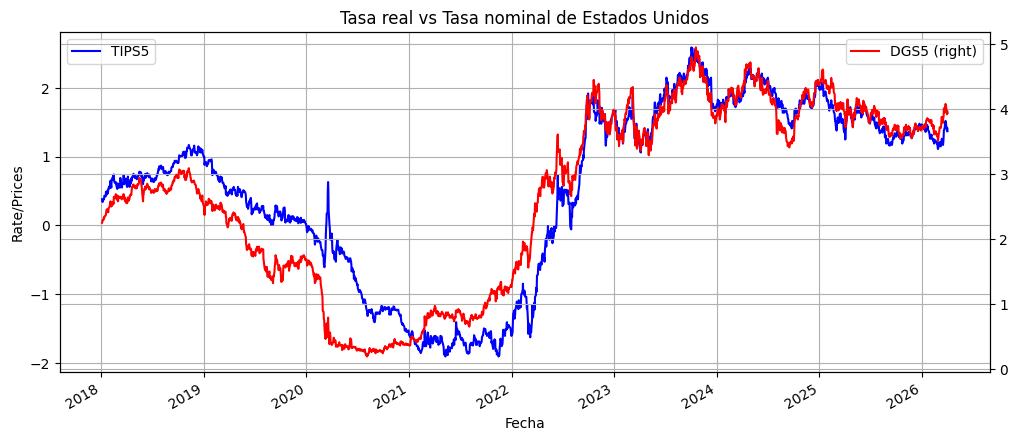

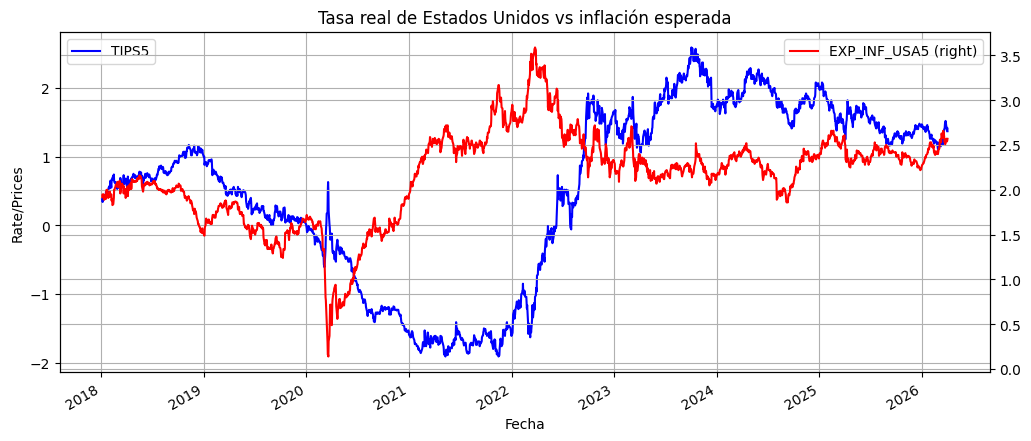

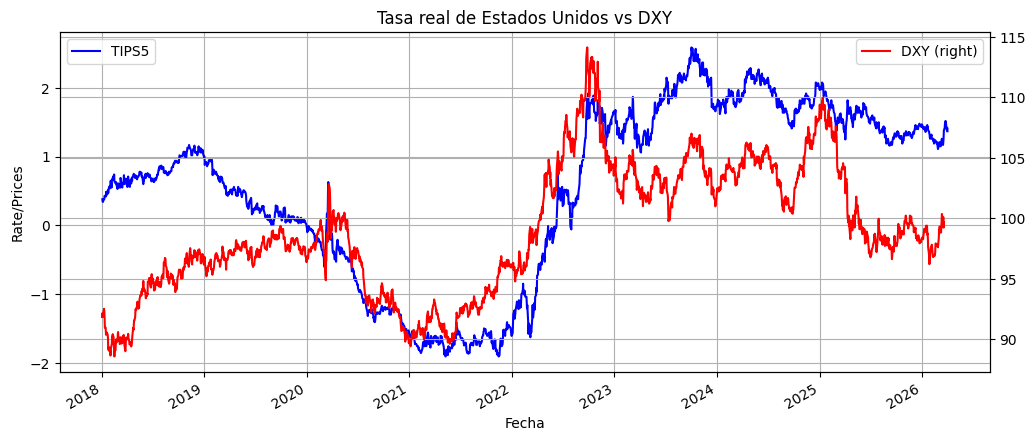

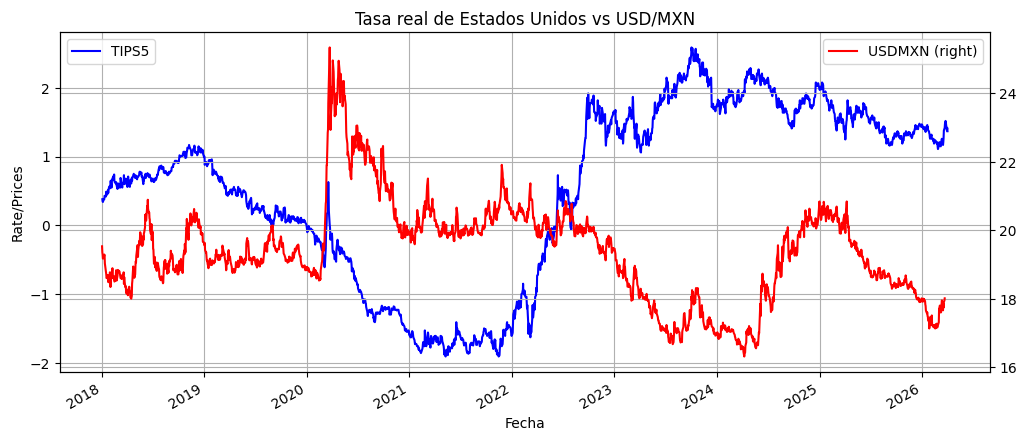

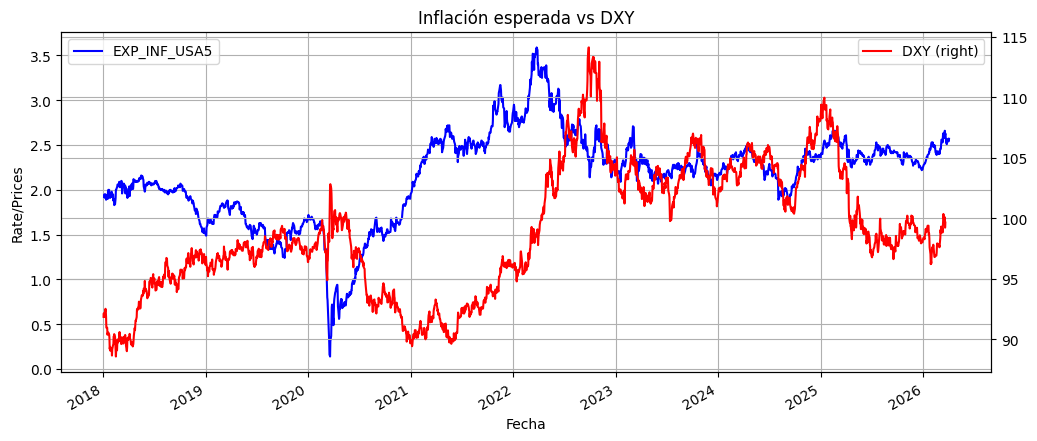

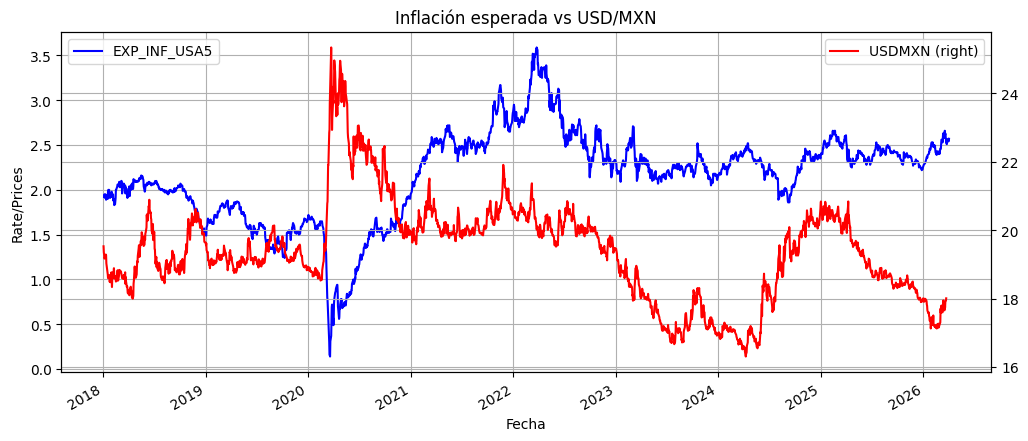

In [116]:
rrm.plot_two_timeseries('TIPS5', 'DGS5', 'Tasa', 'Tasa', titulo = 'Tasa real vs Tasa nominal de Estados Unidos')
rrm.plot_two_timeseries('TIPS5', 'EXP_INF_USA5', 'Tasa', 'Diferencia', titulo = 'Tasa real de Estados Unidos vs inflación esperada') # from_date='2020-01-01', to_date='2020-12-01
rrm.plot_two_timeseries('TIPS5', 'DXY', 'Tasa', 'Cierre', titulo = 'Tasa real de Estados Unidos vs DXY')
rrm.plot_two_timeseries('TIPS5', 'USDMXN', 'Tasa', 'Cierre', titulo = 'Tasa real de Estados Unidos vs USD/MXN')
rrm.plot_two_timeseries('EXP_INF_USA5', 'DXY', 'Diferencia', 'Cierre', titulo = 'Inflación esperada vs DXY')
rrm.plot_two_timeseries('EXP_INF_USA5', 'USDMXN', 'Diferencia', 'Cierre', titulo = 'Inflación esperada vs USD/MXN')

A nivel visual, algunas de estas combinaciones sugieren la posible existencia de relaciones proporcionales e inversas en periodos específicos; sin embargo, dichas asociaciones no resultan concluyentes ni consistentemente visibles a lo largo del tiempo. Esto motiva una evaluación más formal de la relación entre variables.

Para ello, se emplea un análisis con **modelos de regresión lineal simple**, métricas propias del modelo que nos permitirán evaluarlo y gráficos de dispersión para los distintos horizontes temporales.

El tratamiento **automático** de los datos es el siguiente:
* Se estandariza si se trabajan diferentes métricas
* Se usan retornos si se trabaja sobre precios
* Se usa el diferencial en bps si se trabaja sobre tasas o porcentajes

# Marco Analítico: Búsqueda de Poder Explicativo en Ventanas Temporales Deslizantes
El presente análisis emplea un modelo de regresión lineal simple sobre variables estandarizadas, cuyo objetivo central no es la predicción puntual, sino la **cuantificación sistemática del poder explicativo que una variable ejerce sobre otra a lo largo del tiempo**.

La métrica principal es el coeficiente de determinación r^2, complementado por un Score ponderado que ajusta dicho r^2 por el número de observaciones disponibles en cada ventana, penalizando así las relaciones espurias derivadas de muestras reducidas.

La arquitectura de búsqueda opera mediante ventanas temporales deslizantes no superpuestas en su punto de inicio, generando todas las combinaciones posibles de pares de meses dentro de un año calendario. Para el caso mensual (2018, 2020, 2023, 2025), esto implica construir regresiones desde el par enero–febrero hasta el par noviembre–diciembre, acumulando observaciones progresivamente. 

El criterio mínimo de validez es una ventana de aproximadamente 60 días hábiles de mercado (aprox. 3 meses), garantizando robustez estadística. Para el análisis anual se requieren al menos 200 observaciones por ventana, y para 2026 dada la escasez de datos intra-año la división se reduce a comparaciones semanales con un mínimo de un mes de observaciones.

Los resultados se clasifican en dos bloques por período:

* Principal: el activo que aparece como la variable dependiente con mayor frecuencia de presencia como "benchmark líder" a través de todas las ventanas válidas del período. Representa la relación más consistente y estructural identificada.
* Complemento: los demás activos analizados que, en ese mismo período, exhiben relaciones explicativas secundarias pero estadísticamente relevantes, o cuya presencia parcial sugiere regímenes condicionados.

In [134]:
def get_data(x = list, y = list, from_date = 'aaaa-mm-dd', to_date= 'aaaa-mm-dd'):
    results = []
    models_to_plot = []
    for sec in y:
        for bench in x:
            if sec == bench:
                continue
            
            m = rrm.model(bench, sec, 6)
            m.synchronise_timeseries(from_date, to_date)
            m.compute_linear_reg()
            
            results.append({
                "security": sec,
                "benchmark": bench,
                "beta": m.beta,
                "correlation": m.correlation,
                "r2": m.r_squared
            })
            if abs(m.correlation) >= 0.3:
                models_to_plot.append(m)
    print('*'*10, 'Resultados desde', m.timeseries['Fecha'].min().strftime('%Y-%m-%d'), 'hasta', m.timeseries['Fecha'].max().strftime('%Y-%m-%d'), '*'*10)
    n = len(models_to_plot)

    if n == 0:
        print("No hay modelos que cumplan el criterio para graficar")
    else:
        cols = 2
        rows = math.ceil(n / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
        axes = np.atleast_1d(axes).flatten()

        for i, m in enumerate(models_to_plot):
            m.plot_linear_reg(ax=axes[i])

        # eliminar ejes sobrantes
        for ax in axes[n:]:
            fig.delaxes(ax)

        plt.tight_layout(pad=2.0)
        plt.show()

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by='correlation', ascending=False)
    
    return df_results

In [16]:
import pandas as pd
import numpy as np

def buscar_mejor_r2(x, y, start_date, end_date, min_obs=60, min_corr = 0.3, freq = 'MS', order = 'score'):
    ''' 
    freq='QS' - Quarterly Start - 2018-01-01, 2018-04-01, 2018-07-01, 2018-10-01...

    freq='Y' - Fin de año - 2018-12-31, 2019-12-31, 2020-12-31...
    freq='A-DEC' - Annual, cierre en diciembre
    freq='AS-JAN' - Annual, inicio en enero
    freq='A-JUN' - Fin de año fiscal distinto

    freq='W-FRI' - Para cierres de viernes (muy común en mercados)
    Para weekly el ajuste de min_obs podría ser min_obs = 12 equiv. aprox. a 3 meses
    o min_obs = 26 equiv. aprox.a 6 meses

    freq='D' - Para daily - Cuidado con las combinaciones posibles que genera, lo podría hacer inviable.
    Para daily el ajuste de min_obs podría ser min_obs = 60 equiv. aprox. a 3 meses
    o min_obs = 90 equiv. aprox.a 6 meses
    '''
    
    fechas = pd.date_range(start=start_date, end=end_date, freq=freq)  # Monthly Start, esto crea bloques de fechas mensuales... 2018-01-01, 2018-02-01, 2018-03-01, ... etc
    resultados = []

    for sec in y:
        for bench in x:
            if sec == bench:
                continue
            
            for i in range(len(fechas)):
                for j in range(i+1, len(fechas)): # Luego hace combinaciones de todas las ventanas posibles mensuales. 
                    # De un año son 66! n(n-1)/2... enero a febero,..., enero a diciembre y luego de febero a marzo,..., febrero a diciemnbre y asi hasta noviembre a diciembre
                    
                    from_d = fechas[i]
                    to_d = fechas[j]
                    
                    m = rrm.model(bench, sec, 6)
                    m.synchronise_timeseries(from_d, to_d)
                    
                    # filtro de tamaño mínimo
                    if len(m.timeseries) < min_obs: # Si los días hábiles son menores a x dia desechalos para evitar ventanas “perfectas” pero espurias
                        continue
                    
                    m.compute_linear_reg()
                    
                    resultados.append({
                        "security": sec,
                        "benchmark": bench,
                        "r2": m.r_squared,
                        "correlation": m.correlation,
                        "beta": m.beta,
                        "from": m.timeseries['Fecha'].min().strftime('%Y-%m-%d'),
                        "to": m.timeseries['Fecha'].max().strftime('%Y-%m-%d'),
                        "n_obs": len(m.timeseries)
                    })

    df = pd.DataFrame(resultados)

    # filtro de calidad
    df = df[
        (df['n_obs'] >= min_obs) & 
        (abs(df['correlation']) > min_corr)]
    
    # score robusto (penaliza ventanas pequeñas)
    df['score'] = df['r2'] * np.log(df['n_obs'])
    
    # ordenar por mejor ajuste
    # df = df.sort_values(by='r2', ascending=False)
    df = df.sort_values(by=order, ascending=False).reset_index(drop=True)
    
    return df

In [22]:
def analizar_securities(df, metric='r2'):
    """
    Analiza el benchmark más frecuente por security con métricas de representatividad.
    Si hay empate en frecuencia, desempata por la métrica elegida (r2 o correlation).
    """
    # 1. Identificar el security principal
    top_security = df['security'].value_counts().idxmax()
    
    # 2. Calcular el total de filas por cada security (para el denominador)
    totales_por_sec = df['security'].value_counts().to_dict()
    
    # 3. Preparar desempate dinámico
    df_temp = df.copy()
    if metric == 'correlation':
        df_temp['metric_abs'] = df_temp[metric].abs()
    else:
        df_temp['metric_abs'] = df_temp[metric]

    # 4. Agrupar por par security-benchmark
    agrupado = df_temp.groupby(['security', 'benchmark']).agg(
        repeticiones=('benchmark', 'count'),
        max_metrica=('metric_abs', 'max')
    ).reset_index()

    # 5. Ordenar y seleccionar el benchmark ganador
    resumen_base = (agrupado.sort_values(['security', 'repeticiones', 'max_metrica'], 
                                        ascending=[True, False, False])
                    .groupby('security').head(1)).copy()

    # TOTALES Y PORCENTAJES 
    resumen_base['total_obs'] = resumen_base['security'].map(totales_por_sec)
    resumen_base['pct_presencia'] = (resumen_base['repeticiones'] / resumen_base['total_obs']) * 100

    # 6. Función para extraer rangos de fecha y r2
    def get_stats(row):
        mask = (df['security'] == row['security']) & (df['benchmark'] == row['benchmark'])
        sub_df = df[mask]
        idx_min = sub_df['r2'].idxmin()
        idx_max = sub_df['r2'].idxmax()
        
        return pd.Series({
            'min_r2': sub_df.loc[idx_min, 'r2'],
            'corr_min': sub_df.loc[idx_min, 'correlation'],
            'score_min': sub_df.loc[idx_min, 'score'],
            'from_date_min': sub_df.loc[idx_min, 'from'],
            'to_date_min': sub_df.loc[idx_min, 'to'],
            'max_r2': sub_df.loc[idx_max, 'r2'],
            'corr_max': sub_df.loc[idx_max, 'correlation'],
            'score_max': sub_df.loc[idx_max, 'score'],
            'from_date_max': sub_df.loc[idx_max, 'from'],
            'to_date_max': sub_df.loc[idx_max, 'to']
        })

    detalles = resumen_base.apply(get_stats, axis=1)
    
    # Reordenamos columnas para que lo nuevo aparezca al principio junto a repeticiones
    cols_base = ['security', 'benchmark', 'repeticiones', 'total_obs', 'pct_presencia']
    resumen_final = pd.concat([resumen_base[cols_base], detalles], axis=1)
    
    principal = resumen_final[resumen_final['security'] == top_security].reset_index(drop=True)
    complemento = resumen_final[resumen_final['security'] != top_security].reset_index(drop=True)
    
    
    return principal, complemento

# "   Presencia: {row['repeticiones']}/{row['total_obs']} ({row['pct_presencia']:.2f}%)" 
def imprimir_detalles_analisis(df_resultados, titulo="ANÁLISIS DETALLADO"):
    """
    Imprime de forma estructurada los resultados (sirve para Principal o Complemento).
    Muestra R2, Periodos y los Scores asociados.
    """
    if df_resultados.empty:
        print(f"No hay datos para mostrar en: {titulo}")
        return

    print("\n" + "="*70)
    print(f"{titulo:^70}")
    print("="*70)

    for i, row in df_resultados.iterrows():
        print(f"\n📌 SECURITY: {row['security']} | Benchmark: {row['benchmark']}")
        print(f"   Presencia: {row['repeticiones']} de {row['total_obs']} obs. ({row['pct_presencia']:.2f}%)")
        
        print(f"   " + "-"*65)
        # Bloque Min con R (correlación)
        print(f"   📉 Min R2: {row['min_r2']:.4f} [r: {row['corr_min']:.4f}] (Score: {row['score_min']:.4f})")
        print(f"      Periodo: {row['from_date_min']} a {row['to_date_min']}")
        
        # Bloque Max con R (correlación)
        print(f"   📈 Max R2: {row['max_r2']:.4f} [r: {row['corr_max']:.4f}] (Score: {row['score_max']:.4f})")
        print(f"      Periodo: {row['from_date_max']} a {row['to_date_max']}")
    
    print("\n" + "="*80)


In [17]:
def imprimir_resumen_frecuencias(df):
    # Obtener las frecuencias (conteo de cada security)
    counts = df['security'].value_counts()

    print('Conteo de securities:', counts, '\n')

    # Identificar el más frecuente y su valor
    sec_most_frequent = counts.idxmax()
    frequency = counts.max()

    # Calcular el porcentaje vs el total
    total_rows = len(df)
    percentage = (frequency / total_rows) * 100

    print(f"El security (y) más frecuente es: {sec_most_frequent}")
    print(f"Aparece {frequency} veces de un total de {total_rows} ({percentage:.2f}%)")

    # Filtrar y encontrar su benchmark más común
    top_benchmark = df[df['security'] == sec_most_frequent]['benchmark'].value_counts().idxmax()
    conteo_bm = df[df['security'] == sec_most_frequent]['benchmark'].value_counts().max()

    print(f"Del security '{sec_most_frequent}', su benchmark (x) más frecuente es '{top_benchmark}' ({conteo_bm} veces)")

    # Filtramos por las dos variables líderes para tener el bloque específico
    df_most_freq = df[(df['security'] == sec_most_frequent) & (df['benchmark'] == top_benchmark)]


    # Localizar el mejor registro por Score
    row_best_score = df_most_freq.loc[df_most_freq['score'].idxmax()]

    print(f"\nMejor registro por Score:")
    print(f"Sec: {row_best_score['security']} | Bench: {row_best_score['benchmark']} | Score: {row_best_score['score']:.4f} | R2: {row_best_score['r2']:.4f} | Periodo: {row_best_score['from']} a {row_best_score['to']}")


In [91]:
def analizar_temporalidad_lider(df):
    # 1. Identificar el bloque principal (Líderes)
    top_sec = df['security'].value_counts().idxmax()
    top_bench = df[df['security'] == top_sec]['benchmark'].value_counts().idxmax()
    
    # Filtrar el bloque
    bloque_lider = df[(df['security'] == top_sec) & (df['benchmark'] == top_bench)].copy()
    
    # 2. Convertir a datetime y calcular duración
    bloque_lider['from'] = pd.to_datetime(bloque_lider['from'])
    bloque_lider['to'] = pd.to_datetime(bloque_lider['to'])
    bloque_lider['duracion_dias'] = (bloque_lider['to'] - bloque_lider['from']).dt.days
    
    # 3. Score: Calidad (R2) x Persistencia (Duración)
    # Esto penaliza R2s altos en periodos muy cortos
    bloque_lider['score_temporal'] = bloque_lider['r2'] * bloque_lider['duracion_dias']
    
    # 4. Encontrar el mejor registro bajo este criterio
    mejor_registro = bloque_lider.loc[bloque_lider['score_temporal'].idxmax()]
    
    # 5. Análisis de meses más repetidos (frecuencia temporal)
    # Expandimos los rangos para ver qué meses "viven" más en este bloque
    meses_lista = []
    for _, row in bloque_lider.iterrows():
        rango = pd.date_range(start=row['from'], end=row['to'], freq='MS')
        meses_lista.extend(rango)
    
    mes_mas_frecuente = pd.Series(meses_lista).dt.month_name().value_counts().idxmax()

    print(f"--- ANÁLISIS ESTRUCTURAL PARA {top_sec} vs {top_bench} ---")
    print(f"Mejor periodo detectado (R2 ponderado): {mejor_registro['from'].date()} a {mejor_registro['to'].date()}")
    print(f"R2 en este periodo: {mejor_registro['r2']:.4f} ({mejor_registro['duracion_dias']} días)")
    print(f"Mes con mayor recurrencia en el análisis: {mes_mas_frecuente}")
    
    return mejor_registro.to_frame().T


## Enfoque sobre Estados Unidos - Horizonte 5 años
Los activos bajo análisis son:

* TIPS5 (5-Year Breakeven Inflation Rate): proxy de las expectativas de inflación implícitas en el mercado de bonos del Tesoro de EE.UU.
* EXP_INF_USA5 (Expectativas de inflación a 5 años, encuesta o modelo propio): medida complementaria de inflación esperada.
* DXY (U.S. Dollar Index): índice ponderado del dólar frente a una canasta de divisas.
* USDMXN: tipo de cambio dólar-peso mexicano.

In [14]:
benchmarks_x = ['EXP_INF_USA5', 'TIPS5']
securities_y = ['DXY', 'USDMXN', 'EXP_INF_USA5']

## 2018 — Régimen de Normalización: La Inflación Creciente Ancla EXP_INF_USA5

In [18]:
r2_2018 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2018-01-04', end_date='2018-12-31', min_obs = 60, min_corr=0.3)

In [130]:
imprimir_resumen_frecuencias(r2_2018)

Conteo de securities: security
EXP_INF_USA5    21
DXY              2
USDMXN           1
Name: count, dtype: int64 

El security (y) más frecuente es: EXP_INF_USA5
Aparece 21 veces de un total de 24 (87.50%)
Del security 'EXP_INF_USA5', su benchmark (x) más frecuente es 'TIPS5' (21 veces)

Mejor registro por Score:
Sec: EXP_INF_USA5 | Bench: TIPS5 | Score: 2.5184 | R2: 0.6102 | Periodo: 2018-02-01 a 2018-05-01


In [23]:
principal_2018, complemento_2018 = analizar_securities(r2_2018)
imprimir_detalles_analisis(principal_2018, "RESULTADOS PRINCIPAL 2018")
imprimir_detalles_analisis(complemento_2018, "RESULTADOS COMPLEMENTO 2018")


                      RESULTADOS PRINCIPAL 2018                       

📌 SECURITY: EXP_INF_USA5 | Benchmark: TIPS5
   Presencia: 21 de 21 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1550 [r: -0.3937] (Score: 0.7768)
      Periodo: 2018-04-02 a 2018-11-01
   📈 Max R2: 0.6102 [r: -0.7812] (Score: 2.5184)
      Periodo: 2018-02-01 a 2018-05-01


                     RESULTADOS COMPLEMENTO 2018                      

📌 SECURITY: DXY | Benchmark: TIPS5
   Presencia: 1 de 2 obs. (50.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1180 [r: -0.3435] (Score: 0.4850)
      Periodo: 2018-09-04 a 2018-11-30
   📈 Max R2: 0.1180 [r: -0.3435] (Score: 0.4850)
      Periodo: 2018-09-04 a 2018-11-30

📌 SECURITY: USDMXN | Benchmark: EXP_INF_USA5
   Presencia: 1 de 1 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1279 [r: -0.3576] (Score: 0.5277)
      Perio

**Principal**: 
EXP_INF_USA5 explicada por TIPS5 con presencia del 100% y R2 máximo de 0.6102 (Score 2.52) en la ventana febrero–mayo.

*¿Qué explica esto?* 
2018 fue el año en que la Fed ejecutó 4 subidas de tasas consecutivas, llevando los Fed Funds del 1.5% al 2.5%. La inflación subyacente rondaba el 2.1–2.2%. En ese entorno, las expectativas de inflación de encuesta (EXP_INF_USA5) seguían muy de cerca al breakeven de mercado (TIPS5) *porque ambas variables estaban siendo calibradas simultáneamente por la retórica hawkish de la Fed*. (**Hawkish = postura restrictiva para combatir inflación/endurecimiento**)

La ventana de máximo R2 (feb–may 2018) coincide con el período en que el mercado *consolidó sus expectativas de endurecimiento*. **NO es que ya estuvieran contrayendo todo sino que el mercado empezó a creer firmemente que eso iba a pasar**, en otras palabras **“El mercado dejó de dudar y empezó a incorporar de forma consistente que la política monetaria sería más restrictiva”**

La caída posterior al R² mínimo de 0.1550 (abril–noviembre) *es consistente con la divergencia entre los mercados de renta fija y las expectativas de encuesta* (pues el mercado de bonos y las encuestas no dicen lo mismo sobre el futuro) cuando la Fed comenzó a comunicar incertidumbre sobre el ritmo de alzas.

El mercado está incorporando estrés/ruido (liquidez, entrés, flujos) que las encuestas no reflejan (mas puras), por ejemplo en 2020 el breakeven cayó fuerte - baja inflación pero las encuestas opinan una inflación estable o transitoria.

**Complemento** 
USDMXN: explica por EXP_INF_USA5 con R² de 0.1279 en feb–may. Esto tiene sentido directo: en ese mismo trimestre, **el peso mexicano sufrió una depreciación significativa impulsada por la incertidumbre del TLCAN (renegociación del NAFTA)**. 
La expectativa de inflación americana movía el diferencial de tasas real percibido, afectando el USDMXN. El bajo R2 pero presencia en la misma ventana que el máximo principal sugiere que EXP_INF_USA5 funcionó como correa de transmisión entre la política monetaria de la Fed y el tipo de cambio.

## 2020 — Colapso y Recuperación: El Episodio de Mayor Poder Explicativo Global

In [25]:
r2_2020 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2020-01-01', end_date='2020-12-31', min_obs = 60, min_corr=0.3)

In [132]:
imprimir_resumen_frecuencias(r2_2020)

Conteo de securities: security
EXP_INF_USA5    45
USDMXN          24
DXY             16
Name: count, dtype: int64 

El security (y) más frecuente es: EXP_INF_USA5
Aparece 45 veces de un total de 85 (52.94%)
Del security 'EXP_INF_USA5', su benchmark (x) más frecuente es 'TIPS5' (45 veces)

Mejor registro por Score:
Sec: EXP_INF_USA5 | Bench: TIPS5 | Score: 3.2445 | R2: 0.6493 | Periodo: 2020-04-01 a 2020-10-30


In [27]:
principal_2020, complemento_2020 = analizar_securities(r2_2020)

imprimir_detalles_analisis(principal_2020, "RESULTADOS PRINCIPAL 2020")


                      RESULTADOS PRINCIPAL 2020                       

📌 SECURITY: EXP_INF_USA5 | Benchmark: TIPS5
   Presencia: 45 de 45 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.3783 [r: -0.6151] (Score: 1.5673)
      Periodo: 2020-01-02 a 2020-04-01
   📈 Max R2: 0.6559 [r: -0.8099] (Score: 2.7278)
      Periodo: 2020-04-01 a 2020-07-01



**Principal**: 
EXP_INF_USA5 explicada por TIPS5. Presencia absoluta 45/45 y R2 máximo de 0.6559 (Score 2.73) en la ventana abril–julio.

*¿Qué explica esto?*
La caída más dramática de los breakevens ocurrió en marzo de 2020, cuando los breakevens a 10 años colapsaron de 1.7% a 0.5% en dos semanas — *no porque los mercados esperaran deflación*, sino porque una **crisis de liquidez forzó ventas indiscriminadas de TIPS**.

Explicación más detallado de lo que sucedió:
*Los TIPS son menos líqudios, en crisis se venden o no se compran tanto (menor demanda)*, a diferencia de los Nomiales que tienen una demanda fuerte... **Para el breakeven esto implica una caida fuerte, no por inflación si no por flujos.**

<Figure size 640x480 with 0 Axes>

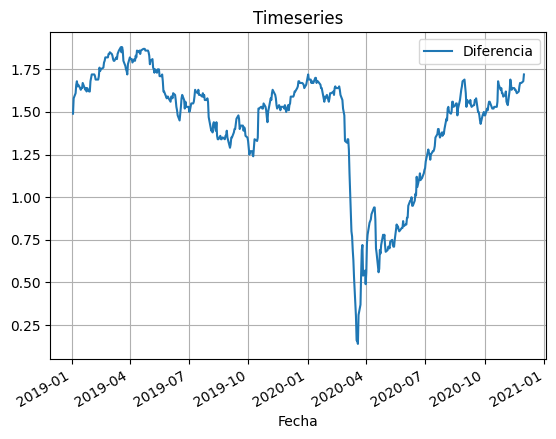

In [8]:
rrm.plot_timeseries_one('EXP_INF_USA5', 'Diferencia', from_date='2019-01-01', to_date='2020-12-01')

A finales de marzo de 2020 la Federal Reserve intervino agresivamente con programas de liquidez y QE ilimitado, había anunciado algo inusual... **Compraría activos (bonos) en la cantidad que fuera necesaria, sin un límite predefinido.** (QE infinito - sin restricción explícita)

La ventana abril–julio captura exactamente ese rebote *desde el mínimo de pánico hasta la estabilización post-QE infinito*, donde **TIPS5 y EXP_INF_USA5 se movieron en perfecta sintonía mientras la Fed anunciaba QE ilimitado y yield curve control implícito**. Muestra entonces la implementación/"resultados" de la intervención más fuerte que hicieron y que se se mantuvo, surtiendo efecto.

A finales de esta ventana, a mediados de 2020 **el mercado envió una señal fuerte de expectativas de inflación más altas, especialmente en horizontes de corto plazo** esto debido a la subida sostenida, menos ruido en liquidez y mejores condiciones de mercado que se habían logrado tras la intervención. 
La señal fue la subida de breakevens (EXP_INF_USA5) de niveles muy bajos a niveles mas altos. *el cual se logra ver dentro del gráfico*

En otras palabras se dice que **esta ventana captura como se desarrolló la intervención mas fuerte que hizo la Fed**, su implementación, donde la liquidez fue restaurada y los precios de mercado volvieron a reflejar fundamentos, permitiendo que las expectativas de inflación y los rendimientos reales se movieran de forma consistente, lo que fortaleció la relación entre ambas variables y permitió como consecuencia una posible lectura del mercado tras su consistencia.

*El R2 de 0.6559 es excepcionalmente alto para datos financieros de alta frecuencia y refleja un régimen de co-movimiento forzado por la intervención de política monetaria sin precedentes.*

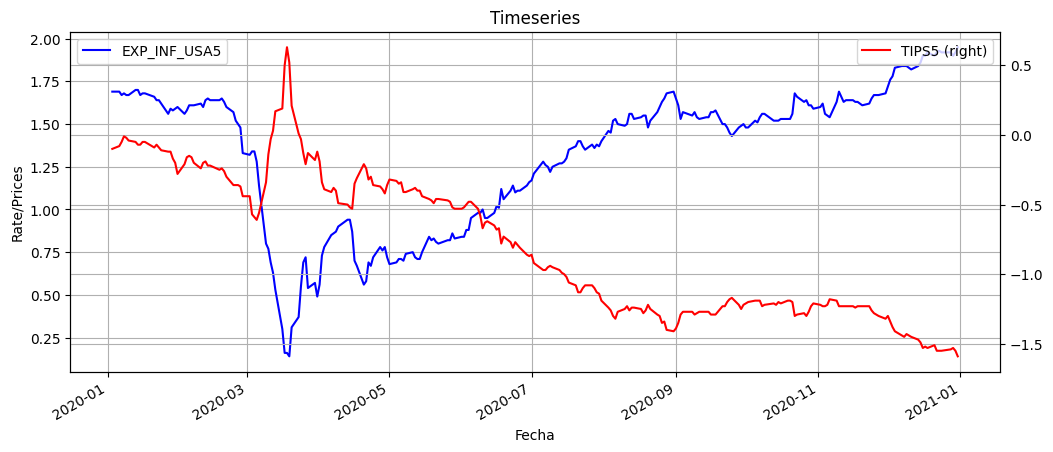

In [11]:

rrm.plot_two_timeseries('EXP_INF_USA5', 'TIPS5', 'Diferencia', 'Tasa', from_date='2020-01-01', to_date='2021-01-01')

Intervenciones... 
* 15 de marzo de 2020
La Federal Reserve baja tasas a 0% y anuncia QE inicial (aprox. 700 mil millones USD), aún NO era “infinito”, *en la gráfica se muestra que ocurre el pico más bajo de la exp. de inflación y el pico mas alto de TIPS5*

Antes del 23 hay ruido extremo

* 23 de marzo de 2020 
Anuncio de QE ilimitado (“infinite QE”). **Este es el verdadero punto de inflexión**
*Lo cual lleva que de abril en adelante el mercaod empiece a normalizarse, lo cual refleja el gráfico*

En resumen...
Marzo 2020 - Pánico total
Finales de marzo - Intervención de la FED agresivamente, anuncio de QE ilimitado y programas de liquidez
Abril–julio - Rebote/resultados de su intervención, el cual fue la estabilización

En crisis (marzo):
TIPS5 - Distorsionado por liquidez - TIPS caen porque nadie quiere liquidez
EXP_INF - Colapsa artificialmente - Breakeven cae fuerte
Causando así que NO hay relación limpia entre ellos, bajo R2

En abril–julio (post QE): La Fed interviene fuerte y el mercado se "estabiliza"
Causando que la liquidez regresara, el mercado funciona mejor, TIPS y EXP_INF reaccionan coherentemente - Se alinean y entonces TIPS5 y EXP_INF empiezan a reflejar lo mismo... expectativas reales de inflación + política monetaria

In [28]:
imprimir_detalles_analisis(complemento_2020, "RESULTADOS COMPLEMENTO 2020")


                     RESULTADOS COMPLEMENTO 2020                      

📌 SECURITY: DXY | Benchmark: TIPS5
   Presencia: 8 de 16 obs. (50.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.0901 [r: -0.3002] (Score: 0.4014)
      Periodo: 2020-05-01 a 2020-09-01
   📈 Max R2: 0.1583 [r: -0.3979] (Score: 0.6610)
      Periodo: 2020-07-01 a 2020-10-01

📌 SECURITY: USDMXN | Benchmark: EXP_INF_USA5
   Presencia: 24 de 24 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1142 [r: 0.3379] (Score: 0.5722)
      Periodo: 2020-03-02 a 2020-10-01
   📈 Max R2: 0.2194 [r: 0.4684] (Score: 0.9090)
      Periodo: 2020-01-02 a 2020-04-01



**Complemento** 
DXY: 
**Posterior a la ventana de intervención de la FED...(Julio 2020 - Octubre2020)**
Presencia solo 50% (8/16), R² bajo (máx 0.1583). Aquí aparece la primera señal interesante: el DXY no fue un buen seguidor de las expectativas inflacionarias en 2020, a pesar de que **teóricamente el dólar debería debilitarse cuando suben las expectativas de inflación real**. 
Esto se explica porque **el DXY en 2020 estuvo dominado por flujos de refugio** (safe haven) más que por diferenciales de inflación. 
DXY NO se explicó por fundamentales como inflación/tasas, sino por miedo, provocando movimiento de dinero hacia activos seguros, principalemnte USD.

Más desarrollado, esto último sucede de la siguiente manera:

*En un shock como el COVID-19 market crash GLOBAL, venden activos riesgosos (acciones, emergentes), buscan liquidez*, **compran dólares y bonos de EUA (Bonos nominales del Tesoro, más líquidos que TIPS) y todo esto genereal demanda masiva por USD y entonces sube el DXY**

**KEY CONCEPT:**
*Los TIPS son menos líqudios, en crisis se venden o no se compran tanto*, esto podría ser clave para explicar y observar que los Nomiales tienen una demanda fuerte y los TIPS menos demanda... **Para el breakeven esto implica una caida fuerte, no por inflación si no por flujos.**

USDMXN:
*Teoricamente, en un mundo ideal... si suben expectativas de inflación en EUA entonces el dólar debería depreciarse, pero en el mundo real esto casi nunca se cumple limpio porque el FX depende de tasa reales, diferenciales de tasas, riesgo, flujos.*

KEY: 
**Entonces el dólar NO reacciona a inflacion, reacciona a tasas reales y política moentaria.**

Pero en este caso, el USDMXN capturó mejor la señal inflacionaria que sucedia antes de la crisis y durante la crisis, **porque el peso es más sensible al apetito por riesgo que el DXY ponderado por divisas desarrolladas.** Dada la situación global... RISK OFF, sale capital de México, se vende el peso lo cual provoca subida de USDMXN fuerte.

A diferencia de risk on, hay optimismo, entra capital, el peso se aprecia y el USDMXN baja.

*Por eso se dice que el peso es un proxy de apetituo por el riesgo.*

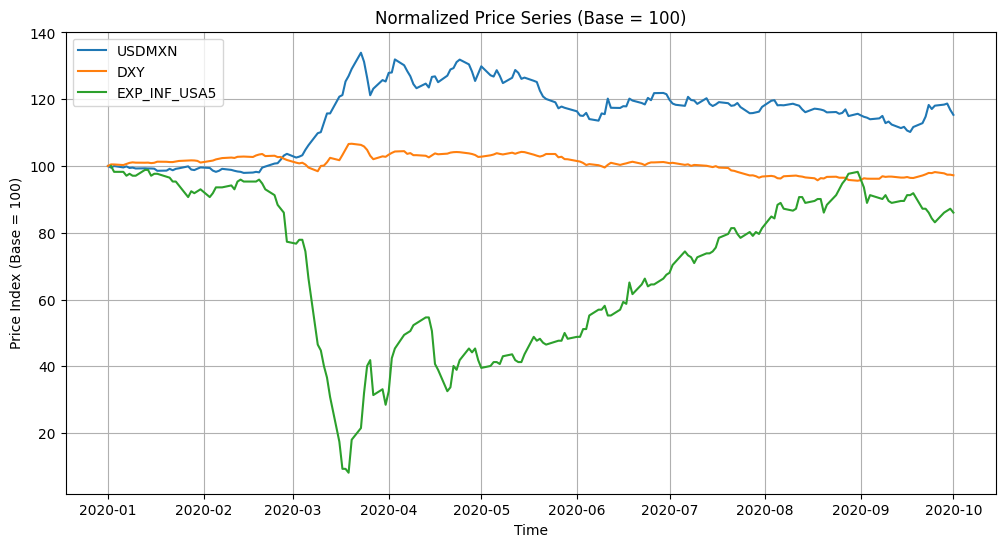

In [39]:
rrm.plot_normalized_timeseries(['USDMXN', 'DXY', 'EXP_INF_USA5'], ['Cierre', 'Cierre', 'Diferencia'], from_date='2020-01-01', to_date='2020-10-01')

## 2023

In [73]:
r2_2023 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2023-01-01', end_date='2023-12-31')

In [136]:
imprimir_resumen_frecuencias(r2_2023)

Conteo de securities: security
DXY             45
USDMXN          19
EXP_INF_USA5     1
Name: count, dtype: int64 

El security (y) más frecuente es: DXY
Aparece 45 veces de un total de 65 (69.23%)
Del security 'DXY', su benchmark (x) más frecuente es 'TIPS5' (45 veces)

Mejor registro por Score:
Sec: DXY | Bench: TIPS5 | Score: 1.6833 | R2: 0.3364 | Periodo: 2023-05-01 a 2023-12-01


In [137]:
principal_2023, complemento_2023 = analizar_securities(r2_2023)

imprimir_detalles_analisis(principal_2023, "RESULTADOS PRINCIPAL 2023")
imprimir_detalles_analisis(complemento_2023, "RESULTADOS COMPLEMENTO 2023")


                      RESULTADOS PRINCIPAL 2023                       

📌 SECURITY: DXY
   Benchmark Líder: TIPS5
   Presencia: 45 de 45 obs. (100.00%)
   -------------------------------------------------------
   📉 Min R2: 0.1878  (Score: 0.7839)
      Periodo: 2023-08-01 a 2023-11-01
   📈 Max R2: 0.3884  (Score: 1.6151)
      Periodo: 2023-05-01 a 2023-08-01


                     RESULTADOS COMPLEMENTO 2023                      

📌 SECURITY: EXP_INF_USA5
   Benchmark Líder: TIPS5
   Presencia: 1 de 1 obs. (100.00%)
   -------------------------------------------------------
   📉 Min R2: 0.1101  (Score: 0.4563)
      Periodo: 2023-04-03 a 2023-06-30
   📈 Max R2: 0.1101  (Score: 0.4563)
      Periodo: 2023-04-03 a 2023-06-30

📌 SECURITY: USDMXN
   Benchmark Líder: TIPS5
   Presencia: 16 de 19 obs. (84.21%)
   -------------------------------------------------------
   📉 Min R2: 0.0998  (Score: 0.4985)
      Periodo: 2023-04-03 a 2023-11-01
   📈 Max R2: 0.3147  (Score: 1.3038)
      Per

## 2025

In [76]:
r2_2025 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2025-01-01', end_date='2026-04-01')

In [237]:
r2_2025.head(10)
# security	benchmark	r2	correlation	beta	from	to	n_obs	score
# 216	USDMXN	EXP_INF_USA5	0.200512	0.447786	0.452674	2025-04-01	2025-07-01	63	0.830748

,security,benchmark,r2,correlation,beta,from,to,n_obs,score
0,DXY,TIPS5,0.282829,-0.531817,-0.750940,2025-08-01,2025-10-31,64,1.176253
1,DXY,TIPS5,0.254334,-0.504316,-0.740979,2025-07-01,2025-10-01,65,1.061689
2,DXY,TIPS5,0.232478,-0.482160,-0.668597,2025-08-01,2025-12-01,83,1.027283
3,DXY,TIPS5,0.213764,-0.462347,-0.627149,2025-08-01,2025-12-31,104,0.992804
4,DXY,TIPS5,0.217420,-0.466284,-0.663528,2025-07-01,2025-10-31,86,0.968464
5,DXY,TIPS5,0.192058,-0.438244,-0.651010,2025-05-01,2025-10-01,106,0.895651
6,DXY,TIPS5,0.187968,-0.433553,-0.609114,2025-07-01,2025-12-01,105,0.874796
7,DXY,EXP_INF_USA5,0.210247,-0.458527,-0.731417,2025-01-02,2025-04-01,62,0.867718
8,DXY,TIPS5,0.179112,-0.423216,-0.618429,2025-05-01,2025-10-31,127,0.867652
9,DXY,TIPS5,0.175748,-0.419223,-0.579958,2025-07-01,2025-12-31,126,0.849967


In [ ]:
# print(r2_2025[r2_2025['security'].isin(['USDMXN', 'EXP_INF_USA5'])])
imprimir_resumen_frecuencias(r2_2025)

Conteo de securities: security
DXY       60
USDMXN    13
Name: count, dtype: int64 

El security (y) más frecuente es: DXY
Aparece 60 veces de un total de 73 (82.19%)
Del security 'DXY', su benchmark (x) más frecuente es 'TIPS5' (43 veces)

Mejor registro por Score:
Sec: DXY | Bench: TIPS5 | Score: 1.1763 | R2: 0.2828 | Periodo: 2025-08-01 a 2025-10-31


In [139]:
principal_2025, complemento_2025 = analizar_securities(r2_2025)
imprimir_detalles_analisis(principal_2025, "RESULTADOS PRINCIPAL 2025")
imprimir_detalles_analisis(complemento_2025, "RESULTADOS COMPLEMENTO 2025")


                      RESULTADOS PRINCIPAL 2025                       

📌 SECURITY: DXY
   Benchmark Líder: TIPS5
   Presencia: 43 de 60 obs. (71.67%)
   -------------------------------------------------------
   📉 Min R2: 0.0950  (Score: 0.4420)
      Periodo: 2025-04-01 a 2025-08-29
   📈 Max R2: 0.2828  (Score: 1.1763)
      Periodo: 2025-08-01 a 2025-10-31


                     RESULTADOS COMPLEMENTO 2025                      

📌 SECURITY: USDMXN
   Benchmark Líder: EXP_INF_USA5
   Presencia: 13 de 13 obs. (100.00%)
   -------------------------------------------------------
   📉 Min R2: 0.0901  (Score: 0.4612)
      Periodo: 2025-04-01 a 2025-12-01
   📈 Max R2: 0.2005  (Score: 0.8307)
      Periodo: 2025-04-01 a 2025-07-01



## Análisis 2026 - Semanal 
Explicaciones dentro de intervalos semanales
Debemos de tener cuidado con r^2 grandes o perfectos con observaciones menores a 5
Si mi numero de observaciones mínimas es de 5 (días), entonces estamos analizando el comportamiento máximo posible del r2 que pudo haber entre las variables dentro de una semana 

In [ ]:
min_dias_obs = 20 # 5 = una semana, 20 = un mes como mínimio entre rangos
r2_2026 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, freq='W-FRI',start_date='2026-01-01', end_date='2026-04-01', order='r2', min_obs=min_dias_obs, min_corr=0)

In [144]:
imprimir_resumen_frecuencias(r2_2026)

Conteo de securities: security
DXY             88
USDMXN          88
EXP_INF_USA5    45
Name: count, dtype: int64 

El security (y) más frecuente es: DXY
Aparece 88 veces de un total de 221 (39.82%)
Del security 'DXY', su benchmark (x) más frecuente es 'EXP_INF_USA5' (44 veces)

Mejor registro por Score:
Sec: DXY | Bench: EXP_INF_USA5 | Score: 1.0464 | R2: 0.3437 | Periodo: 2026-02-20 a 2026-03-20


In [145]:
principal_2026, complemento_2026 = analizar_securities(r2_2026)
imprimir_detalles_analisis(principal_2026, "RESULTADOS PRINCIPAL 2026")
imprimir_detalles_analisis(complemento_2026, "RESULTADOS COMPLEMENTO 2026")


                      RESULTADOS PRINCIPAL 2026                       

📌 SECURITY: DXY
   Benchmark Líder: EXP_INF_USA5
   Presencia: 44 de 88 obs. (50.00%)
   -------------------------------------------------------
   📉 Min R2: 0.0014  (Score: 0.0049)
      Periodo: 2026-01-09 a 2026-03-06
   📈 Max R2: 0.3437  (Score: 1.0464)
      Periodo: 2026-02-20 a 2026-03-20


                     RESULTADOS COMPLEMENTO 2026                      

📌 SECURITY: EXP_INF_USA5
   Benchmark Líder: TIPS5
   Presencia: 45 de 45 obs. (100.00%)
   -------------------------------------------------------
   📉 Min R2: 0.0000  (Score: 0.0000)
      Periodo: 2026-02-13 a 2026-03-20
   📈 Max R2: 0.1004  (Score: 0.3008)
      Periodo: 2026-01-02 a 2026-01-30

📌 SECURITY: USDMXN
   Benchmark Líder: EXP_INF_USA5
   Presencia: 44 de 88 obs. (50.00%)
   -------------------------------------------------------
   📉 Min R2: 0.0004  (Score: 0.0015)
      Periodo: 2026-01-02 a 2026-03-13
   📈 Max R2: 0.1783  (Score: 0.

## Anual 2018-2026

In [ ]:
annual = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2018-01-01', end_date='2026-04-01', min_obs=250, min_corr=0.2, freq='AS-JAN')
# el parametro min_obs SIEMPRE hará alusión a dias mínimos entre intervalos de tiempo, cambiemos o no la frecuencia a anual, mensual o diaria.


/var/folders/kz/rybrs64563zc2gl94rf00qbw0000gn/T/ipykernel_2785/4186853290.py:22: FutureWarning: 'AS-JAN' is deprecated and will be removed in a future version, please use 'YS-JAN' instead.
  fechas = pd.date_range(start=start_date, end=end_date, freq=freq)  # Monthly Start, esto crea bloques de fechas mensuales... 2018-01-01, 2018-02-01, 2018-03-01, ... etc


In [164]:
annual.head(20)

,security,benchmark,r2,correlation,beta,from,to,n_obs,score
0,EXP_INF_USA5,TIPS5,0.401330,-0.633506,-0.591877,2020-01-02,2021-12-31,502,2.495711
1,EXP_INF_USA5,TIPS5,0.439259,-0.662766,-0.651805,2020-01-02,2020-12-31,251,2.427105
2,EXP_INF_USA5,TIPS5,0.358930,-0.599107,-0.518529,2021-01-04,2021-12-31,251,1.983251
3,EXP_INF_USA5,TIPS5,0.297930,-0.545829,-0.413467,2020-01-02,2022-12-30,751,1.972715
4,EXP_INF_USA5,TIPS5,0.277645,-0.526920,-0.459926,2018-01-04,2021-12-31,999,1.917626
5,EXP_INF_USA5,TIPS5,0.280172,-0.529313,-0.473627,2019-01-02,2021-12-31,752,1.855505
6,EXP_INF_USA5,TIPS5,0.255249,-0.505221,-0.382730,2018-01-04,2022-12-30,1248,1.819746
7,DXY,TIPS5,0.292759,-0.541072,-0.473754,2023-01-03,2024-12-31,500,1.819382
8,EXP_INF_USA5,TIPS5,0.254290,-0.504272,-0.381167,2019-01-02,2022-12-30,1001,1.756827
9,DXY,TIPS5,0.314296,-0.560621,-0.451090,2023-01-03,2023-12-29,250,1.735373


In [165]:
imprimir_resumen_frecuencias(annual)

Conteo de securities: security
DXY             36
EXP_INF_USA5    27
USDMXN          15
Name: count, dtype: int64 

El security (y) más frecuente es: DXY
Aparece 36 veces de un total de 78 (46.15%)
Del security 'DXY', su benchmark (x) más frecuente es 'TIPS5' (33 veces)

Mejor registro por Score:
Sec: DXY | Bench: TIPS5 | Score: 1.8194 | R2: 0.2928 | Periodo: 2023-01-03 a 2024-12-31


In [166]:
principal_annual, complemento_annual = analizar_securities(annual)
imprimir_detalles_analisis(principal_annual, "RESULTADOS PRINCIPAL ANUAL")
imprimir_detalles_analisis(complemento_annual, "RESULTADOS COMPLEMENTO ANUAL")


                      RESULTADOS PRINCIPAL ANUAL                      

📌 SECURITY: DXY
   Benchmark Líder: TIPS5
   Presencia: 33 de 36 obs. (91.67%)
   -------------------------------------------------------
   📉 Min R2: 0.0437  (Score: 0.2711)
      Periodo: 2018-01-03 a 2019-12-31
   📈 Max R2: 0.3143  (Score: 1.7354)
      Periodo: 2023-01-03 a 2023-12-29


                     RESULTADOS COMPLEMENTO ANUAL                     

📌 SECURITY: EXP_INF_USA5
   Benchmark Líder: TIPS5
   Presencia: 27 de 27 obs. (100.00%)
   -------------------------------------------------------
   📉 Min R2: 0.0492  (Score: 0.3397)
      Periodo: 2022-01-03 a 2025-12-31
   📈 Max R2: 0.4393  (Score: 2.4271)
      Periodo: 2020-01-02 a 2020-12-31

📌 SECURITY: USDMXN
   Benchmark Líder: EXP_INF_USA5
   Presencia: 8 de 15 obs. (53.33%)
   -------------------------------------------------------
   📉 Min R2: 0.0405  (Score: 0.2683)
      Periodo: 2020-01-02 a 2022-12-30
   📈 Max R2: 0.1149  (Score: 0.6348)
  

# Gráficos relevantes

********** Resultados desde 2020-01-02 hasta 2020-12-31 **********


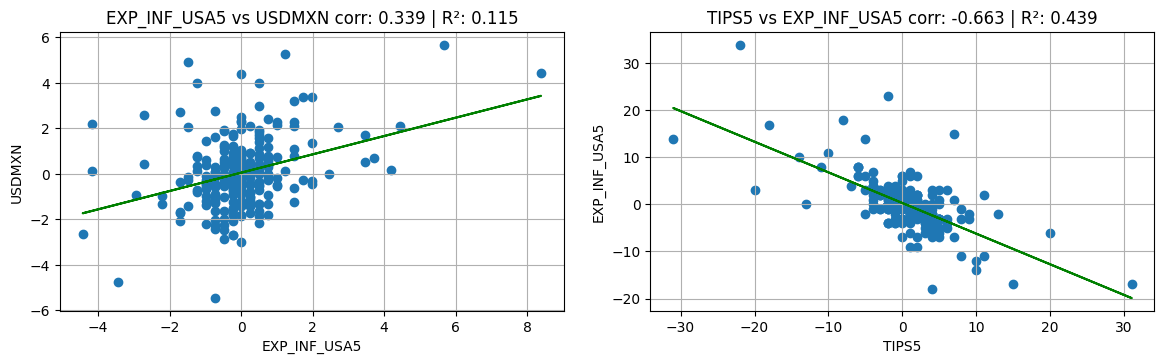

       security     benchmark      beta  correlation        r2
2        USDMXN  EXP_INF_USA5  0.402792     0.338939  0.114880
0           DXY  EXP_INF_USA5  0.033058     0.039647  0.001572
3        USDMXN         TIPS5 -0.157193    -0.093553  0.008752
1           DXY         TIPS5 -0.290354    -0.246290  0.060659
4  EXP_INF_USA5         TIPS5 -0.651805    -0.662766  0.439259


In [ ]:
data_1826 = get_data(x = benchmarks_x, y = securities_y, from_date='2020-01-01', to_date='2020-12-31')
print(data_1826)

********** Resultados desde 2020-01-02 hasta 2020-12-31 **********


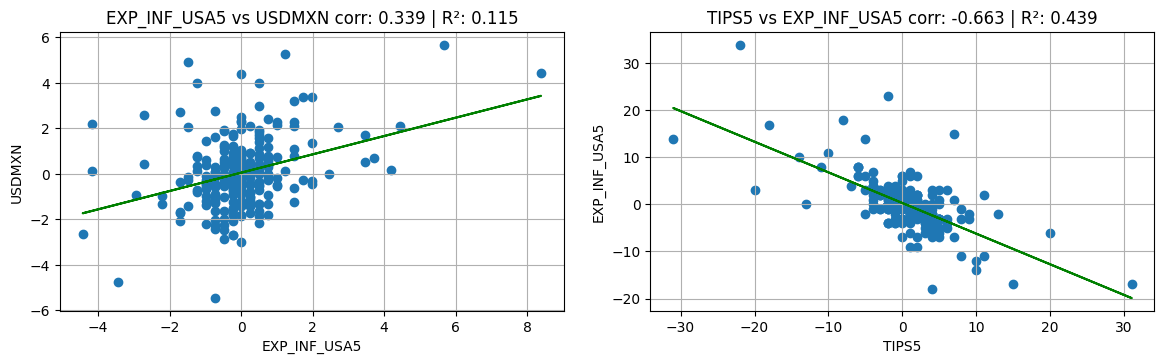

       security     benchmark      beta  correlation        r2
2        USDMXN  EXP_INF_USA5  0.402792     0.338939  0.114880
0           DXY  EXP_INF_USA5  0.033058     0.039647  0.001572
3        USDMXN         TIPS5 -0.157193    -0.093553  0.008752
1           DXY         TIPS5 -0.290354    -0.246290  0.060659
4  EXP_INF_USA5         TIPS5 -0.651805    -0.662766  0.439259


In [153]:
data_2020 = get_data(x = benchmarks_x, y = securities_y, from_date='2020-01-01', to_date='2020-12-31')
print(data_2020)

********** Resultados desde 2024-01-02 hasta 2026-04-02 **********


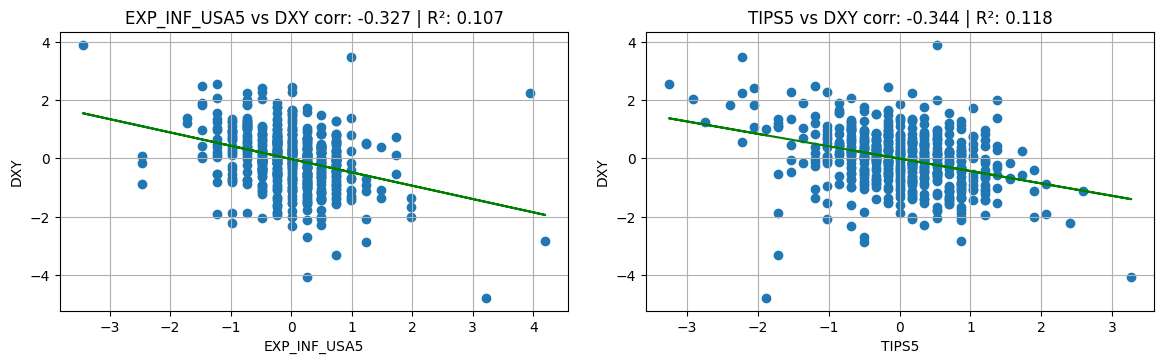

       security     benchmark      beta  correlation        r2
2        USDMXN  EXP_INF_USA5  0.144063     0.111195  0.012364
4  EXP_INF_USA5         TIPS5  0.035248     0.056761  0.003222
3        USDMXN         TIPS5 -0.140703    -0.121211  0.014692
0           DXY  EXP_INF_USA5 -0.456381    -0.327195  0.107056
1           DXY         TIPS5 -0.425596    -0.343990  0.118329


In [155]:
data_2526 = get_data(x = benchmarks_x, y = securities_y, from_date='2024-01-01')
print(data_2526)

In [156]:
data_2026 = get_data(x = benchmarks_x, y = securities_y, from_date='2026-01-01')
print(data_2026)

********** Resultados desde 2026-01-02 hasta 2026-04-02 **********
No hay modelos que cumplan el criterio para graficar
       security     benchmark      beta  correlation        r2
4  EXP_INF_USA5         TIPS5  0.009446     0.012448  0.000155
2        USDMXN  EXP_INF_USA5 -0.121947    -0.096290  0.009272
3        USDMXN         TIPS5 -0.221011    -0.145980  0.021310
0           DXY  EXP_INF_USA5 -0.374060    -0.239533  0.057376
1           DXY         TIPS5 -0.417498    -0.251878  0.063443
